# Packages, constants, and useful routines

In [8]:
!pip install -Uq pymcel rebound
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import plotly.io as pio
import numpy as np
import pickle
import math
from numba import njit

deg = np.pi / 180
rad = 1 / deg

# Calculation of gravitational acceleration using the EGM96 model

First, we must download the coefficients:

In [9]:
!gdown 1iNVBNS7yjlGgQec5mdD400pXwsfgWZVg

Using cookies from C:\Users\User\.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1iNVBNS7yjlGgQec5mdD400pXwsfgWZVg
To: c:\Users\User\OneDrive\Documentos\OTROS\Astrodynamics\NFR\egm96_coeffs_unnorm.pkl

  0%|          | 0.00/4.17M [00:00<?, ?B/s]
 13%|█▎        | 524k/4.17M [00:00<00:01, 2.03MB/s]
 50%|█████     | 2.10M/4.17M [00:00<00:00, 6.35MB/s]
 88%|████████▊ | 3.67M/4.17M [00:00<00:00, 8.61MB/s]
100%|██████████| 4.17M/4.17M [00:00<00:00, 7.70MB/s]


The coefficients are read using this code:

In [10]:
# Open the file
f = open('egm96_coeffs_unnorm.pkl', 'rb')
# Read the data
data = pickle.load(f)
# Load the unnormalized coefficients up to the desired degree
N = 6     # Number of harmonics to use
C = data.get('C')[:N+1,:N+1]
S = data.get('S')[:N+1,:N+1]

The zonal harmonics are:

In [11]:
J2 = -C[2, 0]
J3 = -C[3, 0]
J4 = -C[4, 0]
J5 = -C[5, 0]
J6 = -C[6, 0]
J2, J3/J2, J4/J2, J5/J2, J6/J2

(np.float64(0.0010826266835531513),
 np.float64(-0.0023393627035130206),
 np.float64(-0.0014960111513707072),
 np.float64(-0.00020994871669218306),
 np.float64(0.0004994161397653563))

The potential will be calculated using this optimized NUMBA code with the help of ChatGPT5:

In [12]:
# EGM96 model parameters
GM_DEFAULT = 398600.4415e9  # m^3/s^2
A_DEFAULT = 6378136.3       # m   # Standard values

def prepare_workspace(Nmax):
    ms = np.arange(Nmax+1, dtype=np.int32)
    exps = np.arange(Nmax+1, dtype=np.int32)
    P = np.zeros((Nmax+1, Nmax+1), dtype=np.float64)
    dP_dx = np.zeros_like(P)
    cos_mth = np.zeros(Nmax+1, dtype=np.float64)
    sin_mth = np.zeros(Nmax+1, dtype=np.float64)
    rn = np.zeros(Nmax+1, dtype=np.float64)
    # Small temporary arrays for the JIT-compiled routine
    temp1 = np.zeros(Nmax+1, dtype=np.float64)
    temp2 = np.zeros(Nmax+1, dtype=np.float64)
    return {
        'Nmax': Nmax,
        'ms': ms,
        'exps': exps,
        'P': P,
        'dP_dx': dP_dx,
        'cos_mth': cos_mth,
        'sin_mth': sin_mth,
        'rn': rn,
        'temp1': temp1,
        'temp2': temp2
    }


@njit
def _compute_P_and_derivatives_rec_jit(Nmax, x, P, dP_dx):
    if x > 1.0:
        x = 1.0
    if x < -1.0:
        x = -1.0
    one_minus_x2 = 1.0 - x*x
    if one_minus_x2 < 0.0:
        one_minus_x2 = 0.0
    P[0, 0] = 1.0
    if Nmax >= 1:
        P[1, 0] = x
        if one_minus_x2 > 0.0:
            P[1, 1] = -math.sqrt(one_minus_x2)
        else:
            P[1, 1] = 0.0
    for m in range(2, Nmax+1):
        if one_minus_x2 <= 0.0:
            P[m, m] = 0.0
        else:
            df = 1.0
            for k in range(1, m+1):
                df *= (2*k - 1)
            P[m, m] = ((-1.0)**m) * df * (one_minus_x2 ** (0.5*m))
        if m < Nmax:
            P[m+1, m] = x * (2*m + 1) * P[m, m]
    for m in range(0, Nmax+1):
        start = 2 if m == 0 else m+1
        for n in range(start, Nmax+1):
            P[n, m] = ((2*n - 1) * x * P[n-1, m] - (n + m - 1) * P[n-2, m]) / (n - m)
    denom = one_minus_x2 if one_minus_x2 >= 1e-16 else 1e-16
    for n in range(1, Nmax+1):
        for m in range(0, n+1):
            dP_dx[n, m] = ((n + m) * P[n-1, m] - n * x * P[n, m]) / denom

@njit
def gravity_anomalous_ecef_fast_jit(x_ecef, y_ecef, z_ecef, C, S, P, dP_dx, ms, exps, cos_mth, sin_mth, rn, GM, a):
    r = math.sqrt(x_ecef*x_ecef + y_ecef*y_ecef + z_ecef*z_ecef)
    x = z_ecef / r
    if x > 1.0:
        x = 1.0
    if x < -1.0:
        x = -1.0
    cos_phi = x
    sin_phi = math.sqrt(max(0.0, 1.0 - x*x))
    theta = math.atan2(y_ecef, x_ecef)

    Nmax = P.shape[0] - 1
    _compute_P_and_derivatives_rec_jit(Nmax, x, P, dP_dx)

    for i in range(Nmax+1):
        cos_mth[i] = math.cos(i * theta)
        sin_mth[i] = math.sin(i * theta)

    for i in range(Nmax+1):
        rn[i] = (a / r) ** i

    S_total = 0.0
    Srad_weighted = 0.0

    dV_dphi_acc = 0.0
    dV_dtheta_acc = 0.0
    for n in range(0, Nmax+1):
        S_n_val = 0.0
        dSphi_n_val = 0.0
        dStheta_n_val = 0.0
        mmax = n
        for m in range(0, mmax+1):
            Pnm = P[n, m]
            dPphi = -sin_phi * dP_dx[n, m]
            Cnm = C[n, m]
            Snm = S[n, m]
            ang_cos = cos_mth[m]
            ang_sin = sin_mth[m]
            combo = Cnm * ang_cos + Snm * ang_sin
            S_n_val += Pnm * combo
            dSphi_n_val += dPphi * combo
            if m != 0:
                dStheta_n_val += Pnm * (-m * Cnm * ang_sin + m * Snm * ang_cos)
        if n >= 2:
            S_total += rn[n] * S_n_val
            Srad_weighted += n * rn[n] * S_n_val
            dV_dphi_acc += rn[n] * dSphi_n_val
            dV_dtheta_acc += rn[n] * dStheta_n_val

    dV_dr_anom = -GM / (r*r) * (S_total + Srad_weighted)
    dV_dphi = GM / r * dV_dphi_acc
    dV_dtheta = GM / r * dV_dtheta_acc

    er_x = sin_phi * math.cos(theta)
    er_y = sin_phi * math.sin(theta)
    er_z = cos_phi
    ephi_x = x * math.cos(theta)
    ephi_y = x * math.sin(theta)
    ephi_z = -sin_phi
    etheta_x = -math.sin(theta)
    etheta_y = math.cos(theta)
    etheta_z = 0.0

    inv_r = 1.0 / r
    inv_r_sinphi = 0.0 if abs(sin_phi) < 1e-12 else 1.0 / (r * sin_phi)
    gradV_anom_x = dV_dr_anom * er_x + inv_r * dV_dphi * ephi_x + inv_r_sinphi * dV_dtheta * etheta_x
    gradV_anom_y = dV_dr_anom * er_y + inv_r * dV_dphi * ephi_y + inv_r_sinphi * dV_dtheta * etheta_y
    gradV_anom_z = dV_dr_anom * er_z + inv_r * dV_dphi * ephi_z + inv_r_sinphi * dV_dtheta * etheta_z
    gx = +gradV_anom_x
    gy = +gradV_anom_y
    gz = +gradV_anom_z
    return gx, gy, gz

# Calculate the coefficients for given values

def gravity_anomalous_ecef_numba(pos, C, S, workspace, GM=GM_DEFAULT, a=A_DEFAULT):
    x_ecef, y_ecef, z_ecef = pos
    return gravity_anomalous_ecef_fast_jit(x_ecef, y_ecef, z_ecef,
                                            C, S,
                                            workspace['P'], workspace['dP_dx'],
                                            workspace['ms'], workspace['exps'],
                                            workspace['cos_mth'], workspace['sin_mth'],
                                            workspace['rn'], GM, a)

To use the code, the first thing I need to do is create a `workspace`:

In [13]:
workspace = prepare_workspace(N)

This prepares some constants that will be used for the calculation. With the workspace ready, I can now calculate the gravitational acceleration at any point:

In [14]:
pos = [7000e3,0,2000e3]
gx,gy,gz = gravity_anomalous_ecef_numba(pos, C, S, workspace)
gx, gy, gz

(-0.005593352652062915, -3.0500882978994005e-05, -0.006824038941396103)

Let's test the routine with example (10.2). The initial orbital elements are:

In [15]:
a_0 = 8059e3
e_0 = 0.17136
Omega_0 = 45*deg
inc_0 = 28*deg
omega_0 = 30*deg
f_0 = 40*deg
M = GM_DEFAULT / pc.constantes.G

Let's create the simulation:

In [16]:
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

Let's verify the initial conditions:

In [17]:
sim.particles[1].xyz, sim.particles[1].vxyz

([-2384463.276807219, 5729016.340979552, 3050468.2964087436],
 [-7361.250932895732, -2989.9258347781715, 1643.5104607732935])

Which match those shown on page (492).

Now we can implement a non-gravitational acceleration routine with `rebound`

In [18]:
def aceleracion_no_esferico(simulacion):

  # Retrieve all simulation data
  sim = simulacion.contents

  # Get the particle
  p = sim.particles[1]

  # Calculate the anomalous acceleration
  px, py, pz = gravity_anomalous_ecef_numba(p.xyz, C, S, workspace)

  # Modify the particle acceleration
  p.ax += px
  p.ay += py
  p.az += pz

Let's add it to the simulation:

In [19]:
sim.additional_forces = aceleracion_no_esferico
sim.force_is_velocity_dependent = True

And run the simulation for 48 hours:

In [20]:
deltat = 48*3600
Nt = 1000
ts = np.linspace(sim.t, sim.t + deltat, Nt)
Es = np.zeros((Nt, 5))

for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    o = sim.orbits()[0]
    Es[i] = [o.a, o.e, o.inc, o.Omega, o.omega]


Let's plot the result:

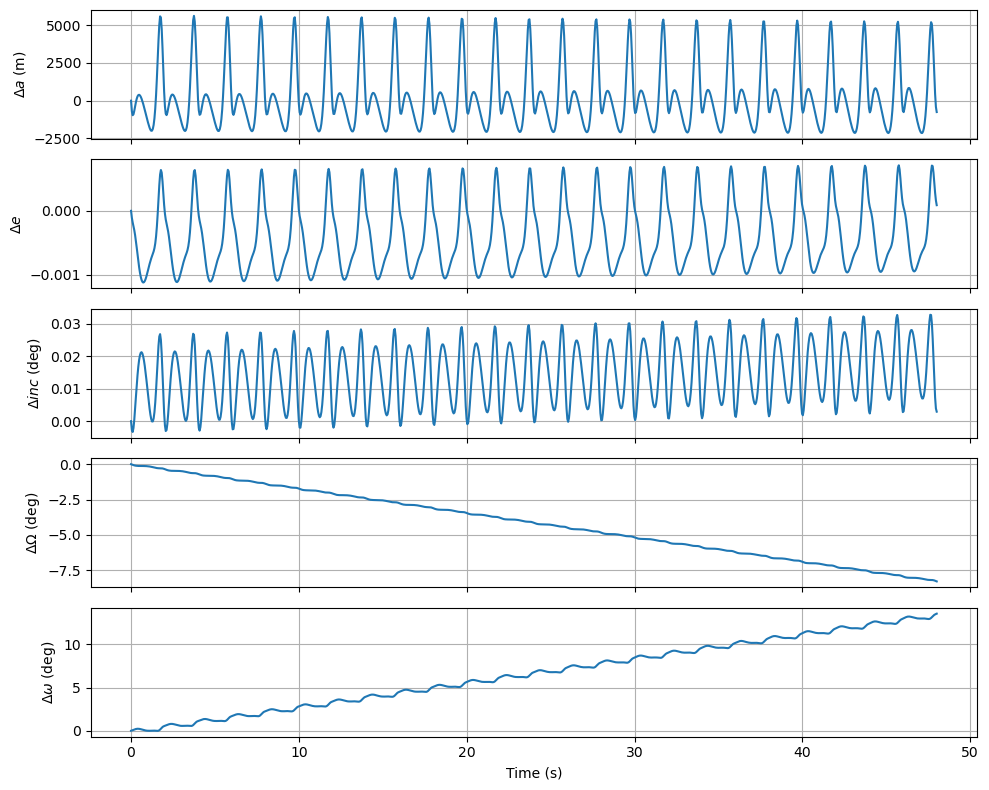

In [21]:
pio.renderers.default = "png"
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

# Difference in a
axes[0].plot(ts/3600, Es[:, 0] - a_0)
axes[0].set_ylabel(r'$\Delta a$ (m)')
axes[0].grid(True)

# Difference in e
axes[1].plot(ts/3600, Es[:, 1] - e_0)
axes[1].set_ylabel(r'$\Delta e$')
axes[1].grid(True)

# Difference in inc in degrees
axes[2].plot(ts/3600, (Es[:, 2] - inc_0) * rad)
axes[2].set_ylabel(r'$\Delta inc$ (deg)')
axes[2].grid(True)

# Difference in Omega in degrees
axes[3].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[3].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[3].grid(True)

# Difference in omega in degrees
axes[4].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[4].set_ylabel(r'$\Delta \omega$ (deg)')
axes[4].set_xlabel('Time (s)')
axes[4].grid(True)

plt.tight_layout()
plt.show()

Which matches what is reported in the text.

## Exercises

In [22]:
mu = pc.constantes.G * pc.constantes.M_earth
R = 6378e3

In [23]:
mu

np.float64(398600400000000.0)

In [24]:
sim0 = rb.Simulation()
sim0.units = 'kg', 'm', 's'
sim0.add(m=M)
sim0.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

In [25]:
def perturbacion(simulacion):

  # Retrieve all simulation data
  sim0 = simulacion.contents

  # Get the particle
  p = sim0.particles[1]

  r_vec = p.xyz
  x, y, z = r_vec[0], r_vec[1], r_vec[2]
  r_mag = np.linalg.norm(r_vec)

  cte = (3 * J2 * mu * R**2 / (2 * r_mag**4))

  # Calculate the anomalous acceleration
  p_j2x = (cte) * (x / r_mag) * (5 * (z**2/r_mag**2) - 1)
  p_j2y = (cte) * (y / r_mag) * (5 * (z**2/r_mag**2) - 1)
  p_j2z = (cte) * (z / r_mag) * (5 * (z**2/r_mag**2) - 3)

  # Modify the particle acceleration
  p.ax += p_j2x
  p.ay += p_j2y
  p.az += p_j2z

In [26]:
sim0.additional_forces = perturbacion
sim0.force_is_velocity_dependent = True

In [27]:
deltat = 48*3600
Nt = 1000
ts = np.linspace(sim0.t, sim0.t + deltat, Nt)
Es_j2 = np.zeros((Nt, 5))

for i, t_step in enumerate(ts):
    sim0.integrate(t_step)
    o = sim0.orbits()[0]
    Es_j2[i] = [o.a, o.e, o.inc, o.Omega, o.omega]


In [28]:
m, b = np.polyfit(ts, Es_j2[:, 3], 1)

pendiente_deg_dia = np.degrees(m) * 3600
print(f"Secular rate of Ω: {pendiente_deg_dia:.5f} °/h")

Secular rate of Ω: -0.17177 °/h


In [29]:
m1, b1 = np.polyfit(ts, Es[:, 4], 1)

omega_hora = np.degrees(m1) * 3600
print(f"Secular rate of ω: {omega_hora:.5f} °/h")

Secular rate of ω: 0.28213 °/h


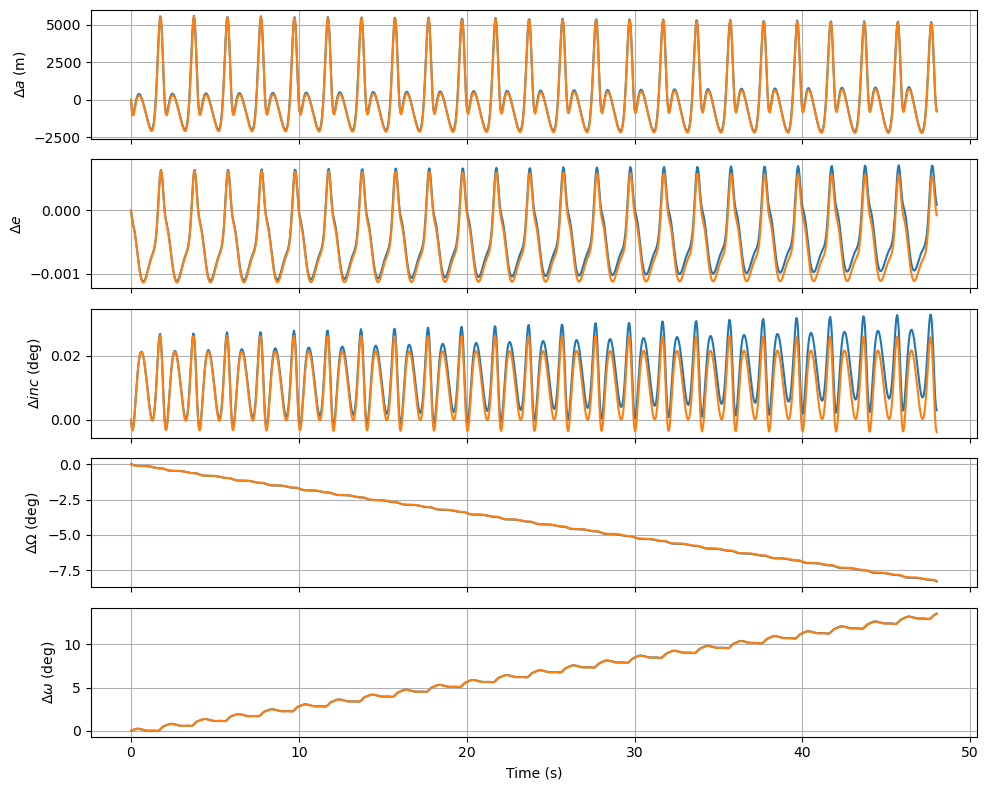

In [30]:
pio.renderers.default = "png"
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

# Difference in a
axes[0].plot(ts/3600, Es[:, 0] - a_0)
axes[0].plot(ts/3600, Es_j2[:, 0] - a_0)
axes[0].set_ylabel(r'$\Delta a$ (m)')
axes[0].grid(True)

# Difference in e
axes[1].plot(ts/3600, Es[:, 1] - e_0)
axes[1].plot(ts/3600, Es_j2[:, 1] - e_0)
axes[1].set_ylabel(r'$\Delta e$')
axes[1].grid(True)

# Difference in inc in degrees
axes[2].plot(ts/3600, (Es[:, 2] - inc_0) * rad)
axes[2].plot(ts/3600, (Es_j2[:, 2] - inc_0) * rad)
axes[2].set_ylabel(r'$\Delta inc$ (deg)')
axes[2].grid(True)

# Difference in Omega in degrees
axes[3].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[3].plot(ts/3600, (Es_j2[:, 3] - Omega_0) * rad)
axes[3].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[3].grid(True)

# Difference in omega in degrees
axes[4].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[4].plot(ts/3600, (Es_j2[:, 4] - omega_0) * rad)
axes[4].set_ylabel(r'$\Delta \omega$ (deg)')
axes[4].set_xlabel('Time (s)')
axes[4].grid(True)

plt.tight_layout()
plt.show()

**Exercise 2**

In [31]:
a_0 = 8059e3
e_0 = 0.17136
Omega_0 = 45*deg
inc_0 = 28*deg
omega_0 = 30*deg
f_0 = 40*deg
u_0 = f_0 + omega_0

In [32]:
h_0 = np.sqrt(mu * a_0 * (1 - e_0**2))
h_0

np.float64(55838993893.2766)

In [33]:
def gauss(t, y):
  h, e, f, Omega, inc, omega = y
  r_mag = h**2/(mu * (1 + e * np.cos(f)))
  u = f + omega

  cte = (3 * J2 * mu * R**2 / (2 * r_mag**3))

  dh_dt = -(cte) * ((np.sin(inc))**2) * ((np.sin(2 * u)))

  de_dt = (cte / h) * ((h**2 / (mu * r_mag)) * np.sin(f) * (3 * (np.sin(inc)**2) * (np.sin(u)**2) - 1)
                        - np.sin(2 * u) * (np.sin(inc)**2) * ((2 + e * np.cos(f)) * np.cos(f) + e))

  df_dt = (h / r_mag**2 + (cte / (e * h)) * ((h**2 / (mu * r_mag)) * np.cos(f) * (3 * (np.sin(inc)**2) * (np.sin(u)**2) - 1)
                                              + (2 + e * np.cos(f)) * np.sin(2*u) * (np.sin(inc)**2) * np.sin(f)))


  dO_dt = -(2 * cte / h) * (np.sin(u)**2) * np.cos(inc)

  di_dt = -(cte/(2 * h)) * np.sin(2 * u) * np.sin(2 * inc)

  dw_dt = ((cte / (e * h))* ((h**2 / (mu * r_mag)) * np.cos(f) * (1 - 3 * (np.sin(inc)**2) * (np.sin(u)**2))
              - (2 + e * np.cos(f)) * np.sin(2*u) * (np.sin(inc)**2) * np.sin(f)
              + 2 * e * (np.cos(inc)**2) * (np.sin(u)**2)))

  return np.array([dh_dt, de_dt, df_dt, dO_dt, di_dt, dw_dt])


In [34]:
from scipy.integrate import solve_ivp

In [35]:
y0 = [h_0, e_0, f_0, Omega_0, inc_0, omega_0]

In [36]:
h_0, e_0, f_0, Omega_0, inc_0, omega_0

(np.float64(55838993893.2766),
 0.17136,
 0.6981317007977318,
 0.7853981633974483,
 0.4886921905584123,
 0.5235987755982988)

In [37]:
deltat = 48*3600
Nt = 1000
ts = np.linspace(0, deltat, Nt)
t_span = [ts[0], ts[-1]]

In [38]:
sol = solve_ivp(gauss, (ts[0], ts[-1]), y0, t_eval=ts, rtol=1e-8, atol=1e-8, method='Radau')

In [39]:
h_0s, e_0s, f_0, Omega_0s, inc_0s, omega_0s = sol.y[:6, :]

In [40]:
Omega_prom = np.mean(Omega_0s)
Omega_prom

np.float64(0.7133322870948041)

In [41]:
a_0s = h_0s**2/(mu * (1 - e_0s**2))

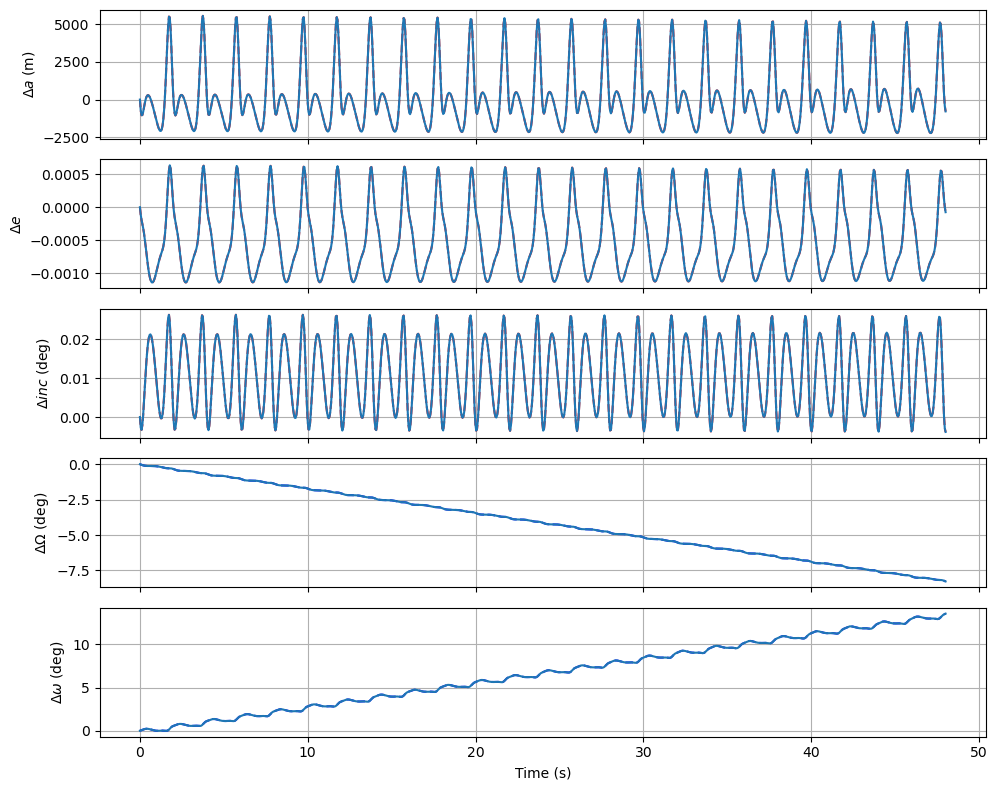

In [42]:
pio.renderers.default = "png"
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

# Difference in a
axes[0].plot(ts/3600, Es_j2[:, 0] - a_0, 'r--')
axes[0].plot(ts/3600, a_0s - a_0)
axes[0].set_ylabel(r'$\Delta a$ (m)')
axes[0].grid(True)

# Difference in e
axes[1].plot(ts/3600, Es_j2[:, 1] - e_0, 'r--')
axes[1].plot(ts/3600, e_0s - e_0)
axes[1].set_ylabel(r'$\Delta e$')
axes[1].grid(True)

# Difference in inc in degrees
axes[2].plot(ts/3600, (Es_j2[:, 2] - inc_0) * rad, 'r--')
axes[2].plot(ts/3600, (inc_0s- inc_0) * rad)
axes[2].set_ylabel(r'$\Delta inc$ (deg)')
axes[2].grid(True)

# Difference in Omega in degrees
axes[3].plot(ts/3600, (Es_j2[:, 3] - Omega_0) * rad, 'b--')
axes[3].plot(ts/3600, (Omega_0s - Omega_0) * rad)
axes[3].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[3].grid(True)

# Difference in omega in degrees
axes[4].plot(ts/3600, (Es_j2[:, 4] - omega_0) * rad, 'b--')
axes[4].plot(ts/3600, (omega_0s - omega_0) * rad)
axes[4].set_ylabel(r'$\Delta \omega$ (deg)')
axes[4].set_xlabel('Time (s)')
axes[4].grid(True)

plt.tight_layout()
plt.show()